# [Basic classification: Classify images of clothing](https://www.tensorflow.org/tutorials/keras/classification)

In [2]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


In [3]:
fashion_mist = tf.keras.datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [11]:
train_images.shape

(60000, 28, 28)

Preprocess the data

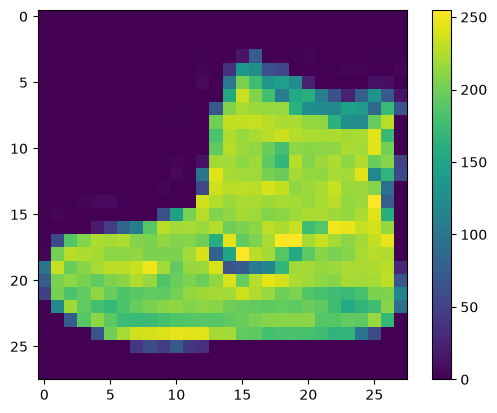

In [20]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False) 
plt.show()

In [21]:
train_images = train_images/255.0

test_images = test_images/255.0

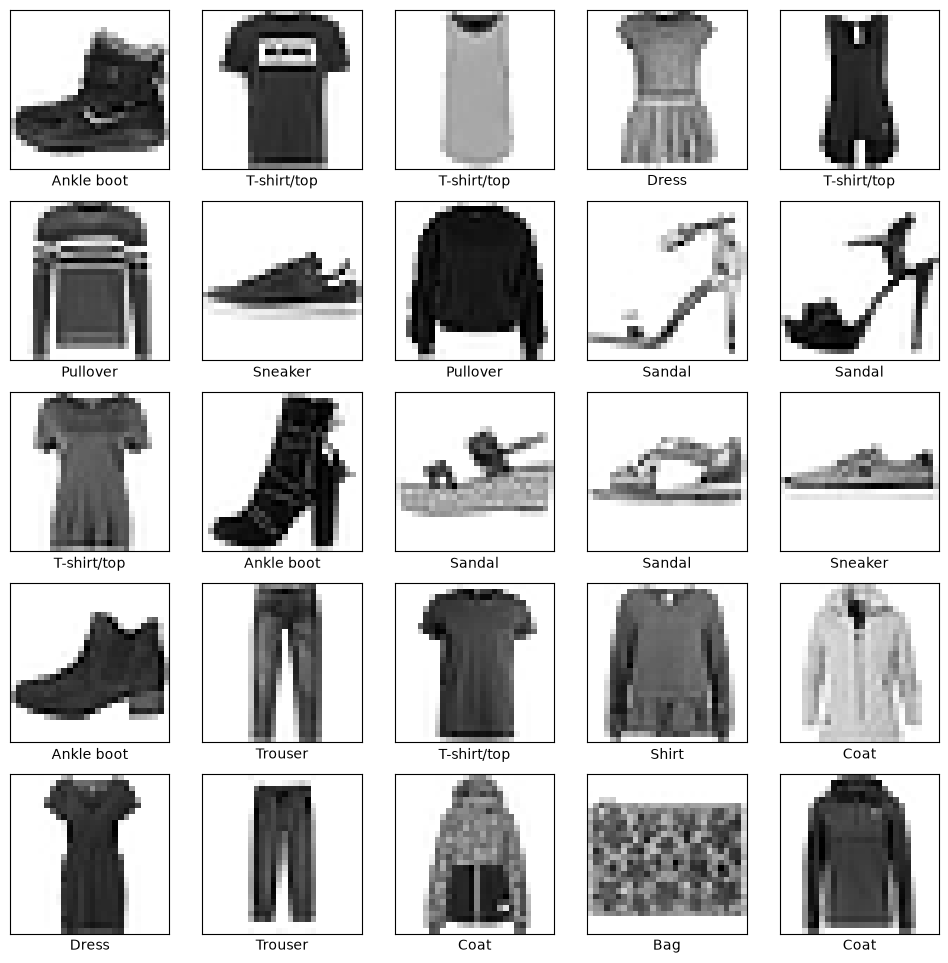

In [35]:
plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    # sterge scara pe ox si oy
    plt.xticks([])
    plt.yticks([])

    plt.grid(False)
    plt.imshow(train_images[i],cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

Build the model

Set up the layers

In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10)
])

g:\facultate\anul 3 sem 2\Practica de specialiate\L4-AdvancedMachineLearning\.venv_tf\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [39]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8278 - loss: 0.4966
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8651 - loss: 0.3728
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8781 - loss: 0.3356
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8842 - loss: 0.3129
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8911 - loss: 0.2954
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8957 - loss: 0.2814
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9012 - loss: 0.2680
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9047 - loss: 0.2581
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9069 - loss: 0.2471
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9117 - loss: 0.2390


In [40]:
test_loss,test_acc = model.evaluate(test_images,test_labels,verbose=2)

print('\n Test accuracy:',test_acc)

313/313 - 0s - 1ms/step - accuracy: 0.8768 - loss: 0.3546

 Test accuracy: 0.876800000667572


Make predicitions

In [58]:
probability_model = tf.keras.Sequential([model,tf.keras.layers.Softmax()])

In [66]:
predictions = probability_model.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step


In [67]:
predictions

array([[6.92604726e-06, 7.21878621e-07, 4.96565281e-06, ...,
        1.41579816e-02, 1.44024767e-07, 9.74589765e-01],
       [1.38892656e-05, 1.85033954e-12, 9.95200872e-01, ...,
        6.23950544e-13, 4.13868467e-10, 8.49119782e-15],
       [6.30017416e-09, 1.00000000e+00, 1.08671015e-11, ...,
        2.80668790e-23, 1.15741479e-11, 5.55503646e-18],
       ...,
       [3.36573436e-07, 1.51325497e-09, 2.69644591e-08, ...,
        3.69151621e-07, 9.99999046e-01, 1.38173793e-12],
       [2.73909539e-09, 9.99995112e-01, 1.18109178e-09, ...,
        5.45781038e-14, 1.80911264e-09, 4.52430418e-14],
       [4.93414245e-06, 1.54864832e-08, 4.97963265e-06, ...,
        6.19654427e-04, 5.92167962e-05, 2.77687445e-06]],
      shape=(10000, 10), dtype=float32)

In [68]:
predictions[0]

array([6.92604726e-06, 7.21878621e-07, 4.96565281e-06, 3.66282477e-10,
       1.91695426e-06, 1.12296725e-02, 7.96739187e-06, 1.41579816e-02,
       1.44024767e-07, 9.74589765e-01], dtype=float32)

In [70]:
for i in range(10):
 print(np.argmax(predictions[i]))


9
2
1
1
6
1
4
6
5
7


In [90]:
def plot_image(i,predictions_array,true_label,img):
    true_label, img = true_label[i],img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img,cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
        
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array,true_label):
    true_label=true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot= plt.bar(range(10),predictions_array,color="#777777")
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')
    

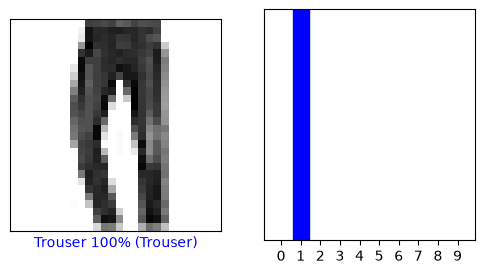

In [92]:
i =5 
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

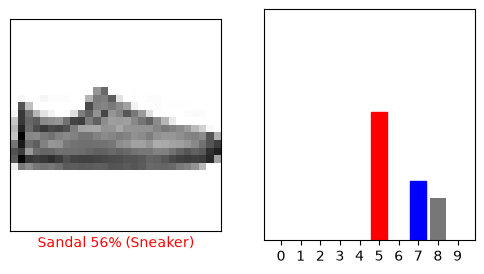

In [96]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

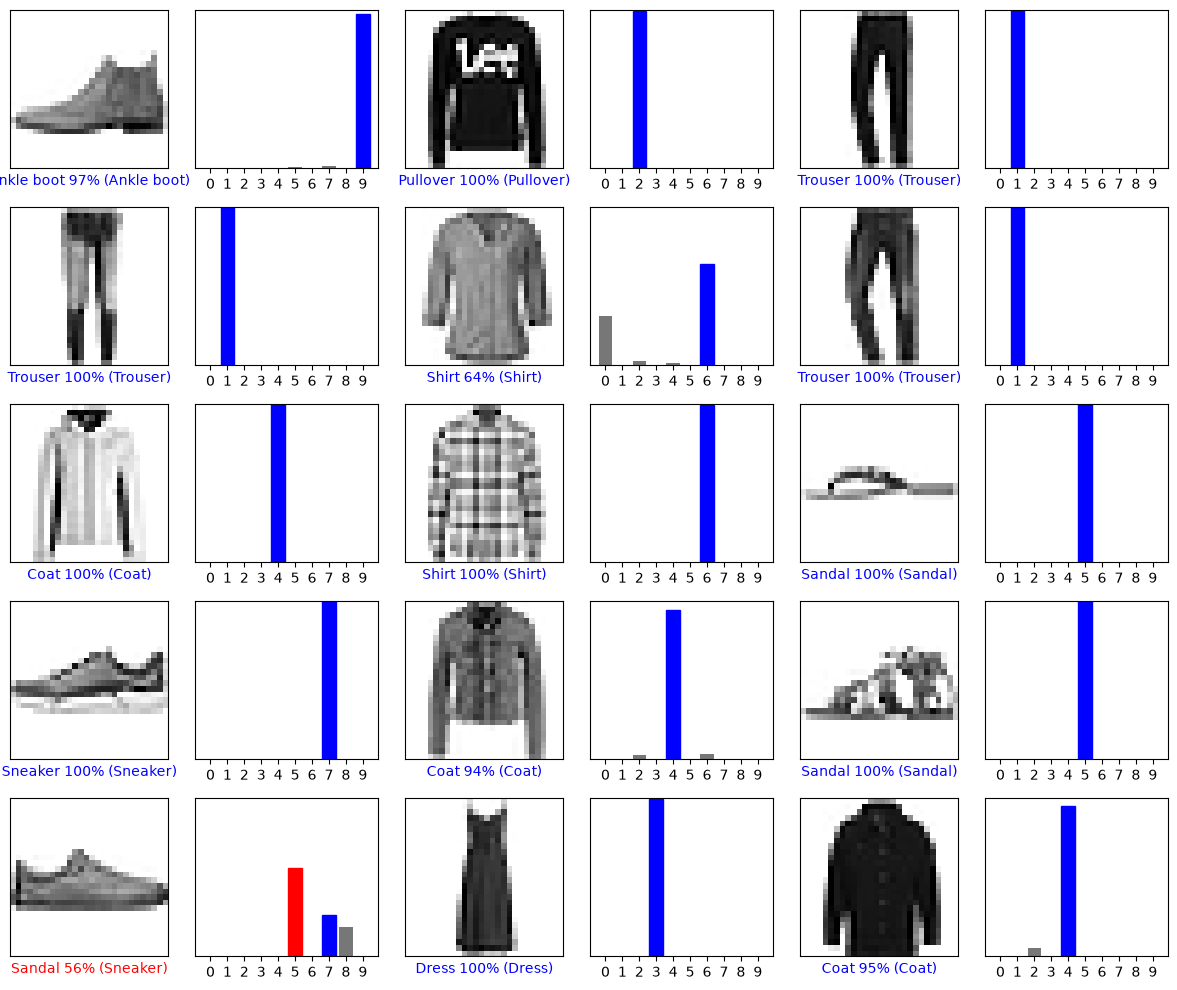

In [97]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

Use the trained model

In [157]:
img = test_images[i]
print(img.shape)

(28, 28)


In [158]:
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


In [161]:
# for i in range(len(img)):
predictions_single = probability_model.predict(img)
print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[6.9260454e-06 7.2187777e-07 4.9656610e-06 3.6628309e-10 1.9169538e-06
  1.1229691e-02 7.9674064e-06 1.4158005e-02 1.4402487e-07 9.7458953e-01]]


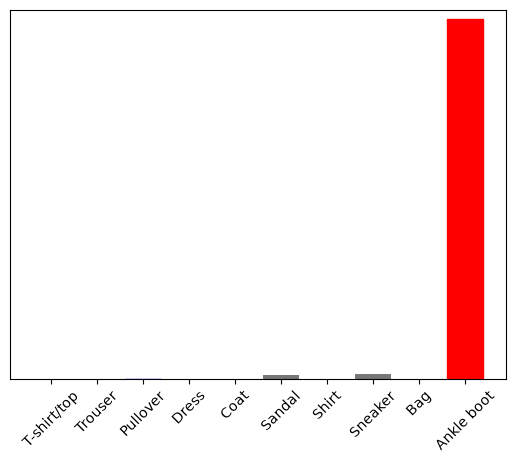

In [162]:
# for i in range(10):
plot_value_array(1, predictions_single[i], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

In [163]:
np.argmax(predictions_single[0])

np.int64(9)